In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/gitbugs/gitbugs/ms_vscode_bugs/vscode_bugs-combined.csv
/kaggle/input/gitbugs/gitbugs/ms_vscode_bugs/vscode_bugs.csv
/kaggle/input/gitbugs/gitbugs/firefox/Firefox_bugs-combined.csv
/kaggle/input/gitbugs/gitbugs/firefox/Firefox_bugs.csv
/kaggle/input/gitbugs/gitbugs/seamonkey/SeaMonkey_bugs.csv
/kaggle/input/gitbugs/gitbugs/seamonkey/SeaMonkey_bugs-combined.csv
/kaggle/input/gitbugs/gitbugs/thunderbird/Thunderbird_bugs.csv
/kaggle/input/gitbugs/gitbugs/thunderbird/Thunderbird_bugs-combined.csv
/kaggle/input/gitbugs/gitbugs/hbase/hbase_bugs-combined.csv
/kaggle/input/gitbugs/gitbugs/hbase/hbase_bugs.csv
/kaggle/input/gitbugs/gitbugs/spark/spark_bugs.csv
/kaggle/input/gitbugs/gitbugs/spark/spark_bugs-combined.csv
/kaggle/input/gitbugs/gitbugs/cassandra/cassandra_bugs.csv
/kaggle/input/gitbugs/gitbugs/cassandra/cassandra_bugs-combined.csv
/kaggle/input/gitbugs/gitbugs/hadoop/hadoop_bugs-combined.csv
/kaggle/input/gitbugs/gitbugs/hadoop/hadoop_bugs.csv
/kaggle/input/gitbugs/gi

In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "/gitbugs/cassandra/cassandra_bugs.csv"

# Load the latest version
bugs_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "av9ash/gitbugs",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)


file_path = "/gitbugs/cassandra/cassandra_bugs-combined.csv"
duplicates_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "av9ash/gitbugs",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", duplicates_df.head())

/tmp/ipykernel_13/113547116.py:10: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  bugs_df = kagglehub.load_dataset(


First 5 records:    Issue id Duplicate id
0  13599387     13517685
1  13599384     13486649
2  13547359     13547360
3  13560194     13427513
4  13560202     13538565


/tmp/ipykernel_13/113547116.py:22: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  duplicates_df = kagglehub.load_dataset(


## Step 1: Load Data

In [3]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt


## Step 2: Preprocessing

In [4]:

# Merge Summary and Description
bugs_df["text"] = bugs_df[["Summary", "Description"]].fillna("").agg(" ".join, axis=1)

# Map issue ID to text
issue_text_map = dict(zip(bugs_df["Issue id"], bugs_df["text"]))

# Clean duplicate ID column: handle comma-separated IDs
duplicates_df["Duplicate id"] = duplicates_df["Duplicate id"].astype(str).str.split(r",\s*")
duplicates_df = duplicates_df.explode("Duplicate id")

# Convert to integers and drop invalid rows
duplicates_df["Issue id"] = pd.to_numeric(duplicates_df["Issue id"], errors='coerce')
duplicates_df["Duplicate id"] = pd.to_numeric(duplicates_df["Duplicate id"], errors='coerce')
duplicates_df = duplicates_df.dropna().astype(int)

# Filter for valid IDs present in text map
duplicates_df = duplicates_df[
    (duplicates_df["Issue id"].isin(issue_text_map)) &
    (duplicates_df["Duplicate id"].isin(issue_text_map))
]

## Step 3: TF-IDF Vectorization

In [5]:

all_ids = list(issue_text_map.keys())
all_texts = [issue_text_map[iid] for iid in all_ids]

vectorizer = TfidfVectorizer(stop_words="english", max_features=10000)
tfidf_matrix = vectorizer.fit_transform(all_texts)

# Index mapping
id_to_index = {iid: idx for idx, iid in enumerate(all_ids)}

## Step 4: IR-based Retrieval

In [6]:

results = []

for _, row in duplicates_df.iterrows():
    qid = row["Issue id"]
    true_duplicate = row["Duplicate id"]

    if qid not in id_to_index or true_duplicate not in id_to_index:
        continue

    q_idx = id_to_index[qid]
    q_vec = tfidf_matrix[q_idx]

    similarities = cosine_similarity(q_vec, tfidf_matrix).flatten()
    top_indices = similarities.argsort()[::-1][1:11]  # Exclude self
    top_ids = [all_ids[i] for i in top_indices]
    top_scores = similarities[top_indices]

    found = true_duplicate in top_ids

    results.append({
        "query_id": qid,
        "true_duplicate": true_duplicate,
        "found_in_top_10": found,
        "top_10_ranked_ids": top_ids,
        "top_10_scores": top_scores.tolist()
    })


## Step 5: Evaluate Recall@10

Recall@10: 0.61 over 300 queries


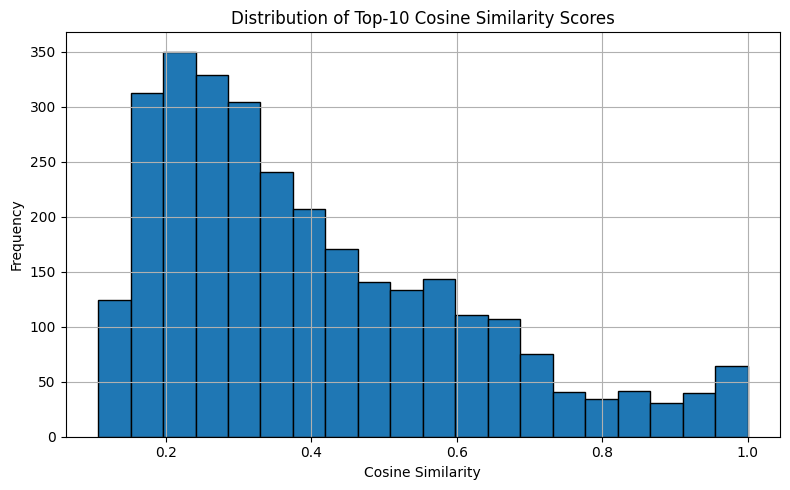

In [7]:

recall_at_10 = sum(r["found_in_top_10"] for r in results) / len(results)
print(f"Recall@10: {recall_at_10:.2f} over {len(results)} queries")

# Step 6: Score Distribution Plot
all_scores = [score for r in results for score in r["top_10_scores"]]

plt.figure(figsize=(8, 5))
plt.hist(all_scores, bins=20, edgecolor='black')
plt.title("Distribution of Top-10 Cosine Similarity Scores")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()
